Setup complete. Output directory: /content/outputs
Implied operating profit: 169,000k vs reported 195,300k (variance -26,300k, reflects rounding/other operating income & costs per IFRS)

--- Derived Average-Shop Driver Set (FY2024 baseline) ---
Revenue per shop (p.a.):        GBP 774,769
Avg transaction value (ATV):    GBP 3.20
Implied units sold per shop:    242,115
Variable cost ratio:            39.57%
Variable cost per unit:         GBP 1.27
Fixed cost per shop (p.a.):      GBP 403,192

Synthetic dataset created: 2,600 shop records, 5 driver columns
     shop_id  units_sold  price_per_unit_gbp  variable_cost_per_unit_gbp  \
0  GRG-00001      260155                3.01                        1.17   
1  GRG-00002      237094                3.26                        1.26   
2  GRG-00003      265638                3.14                        1.25   
3  GRG-00004      297428                3.08                        1.27   
4  GRG-00005      233612                3.14                

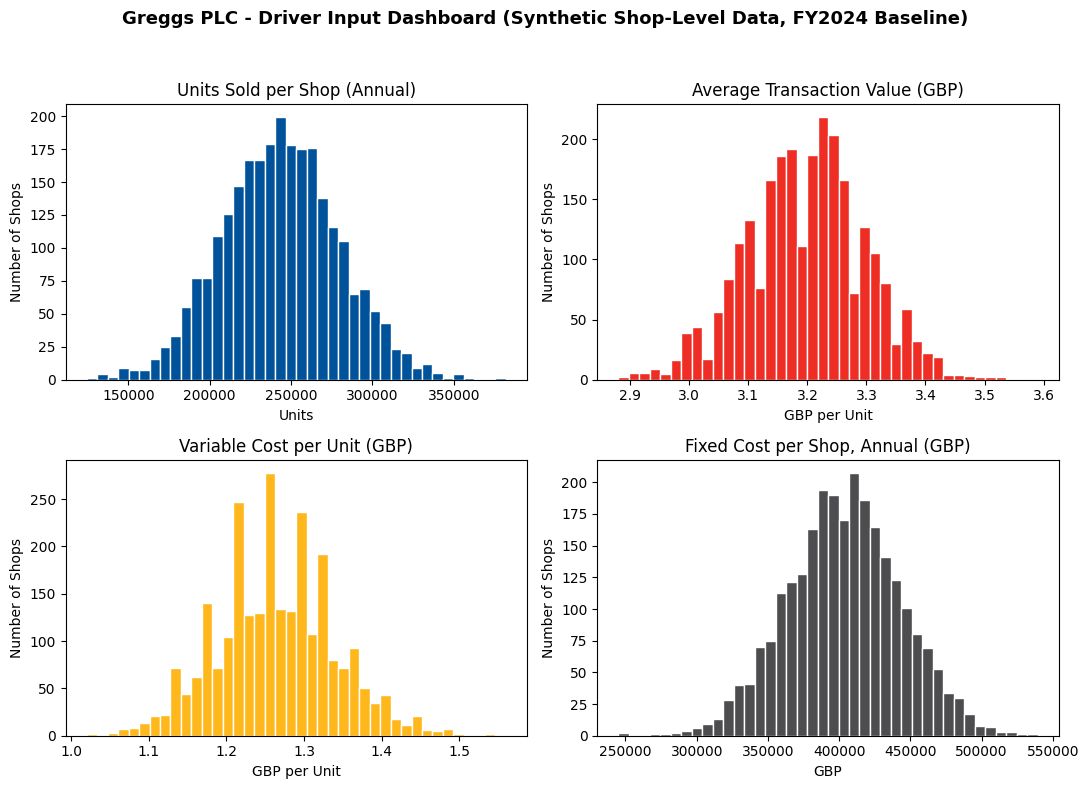

Input dashboard chart saved to: /content/outputs/input_dashboard.png


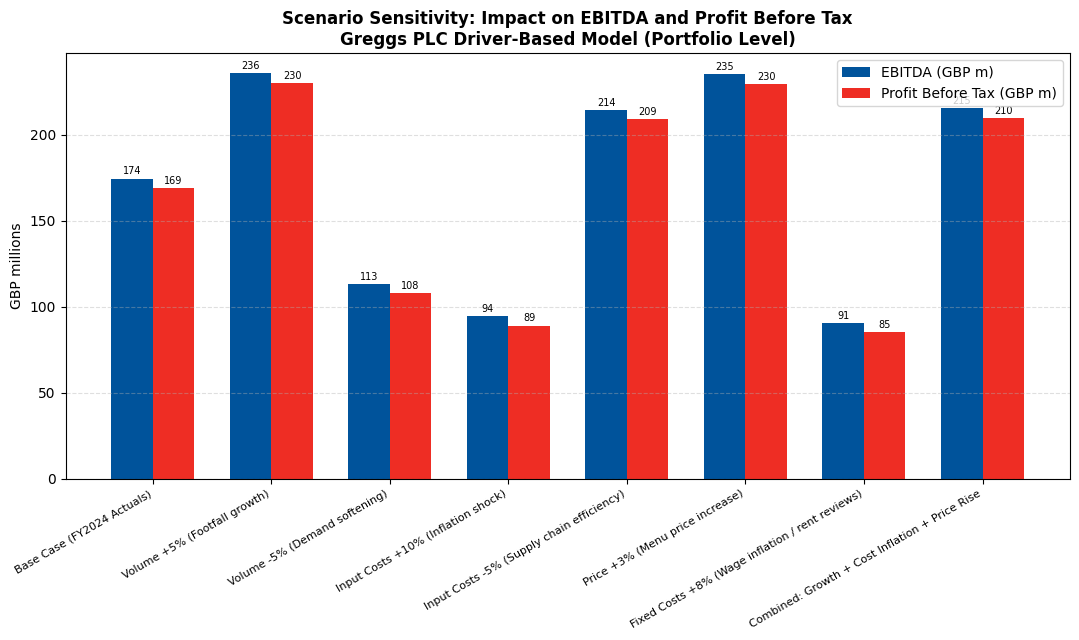

Scenario sensitivity chart saved to: /content/outputs/scenario_sensitivity_chart.png

=== SIMULATION COMPLETE. All outputs saved to: /content/outputs ===


In [1]:
# ============================================================
# DRIVER-BASED OPERATIONAL & FINANCIAL SIMULATOR
# Company: Greggs PLC (LSE: GRG)
# Prepared by: Ayoub Feddal, Financial Analyst
# Run this entire script in Google Colab (Runtime > Run all)
# ============================================================

# ------------------------------------------------------------
# SETUP: Install / import required packages with error handling
# ------------------------------------------------------------
import subprocess
import sys

def ensure_package(pkg):
    """Install a package if it isn't already available."""
    try:
        __import__(pkg)
    except ImportError:
        print(f"[Setup] Installing missing package: {pkg} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

for pkg in ["pandas", "numpy", "matplotlib"]:
    ensure_package(pkg)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import traceback

# Create output folder (auto-fix if it doesn't exist)
OUTPUT_DIR = "/content/outputs"
try:
    os.makedirs(OUTPUT_DIR, exist_ok=True)
except Exception as e:
    print(f"[Setup] Could not create /content/outputs, falling back to current dir. Error: {e}")
    OUTPUT_DIR = "."

print("Setup complete. Output directory:", OUTPUT_DIR)

# ============================================================
# PHASE 1: DATA SETUP
# ============================================================
# Baseline figures are anchored to Greggs plc FY2024 Annual Report
# (Annual Report & Accounts 2024, published March 2025):
#   - Total revenue (turnover):           GBP 2,014.4m
#   - Cost of sales:                      GBP  797.1m  (=> Gross margin ~61.6%)
#   - Operating expenses (admin/selling): GBP 1,048.3m
#   - Operating profit:                   GBP  195.3m
#   - Profit before tax:                  GBP  189.8m
#   - Shop estate (year-end 2024):        ~2,600 shops
#
# To translate these company-level figures into a "driver-based" model,
# we derive an implied AVERAGE SHOP as the base unit of the simulation.
# This keeps assumptions minimal and grounded in reported numbers, rather
# than inventing arbitrary unit economics.
#
# All figures below in GBP thousands (k) unless stated otherwise.

try:
    # --- Company-level FY2024 baseline (reported) ---
    TOTAL_REVENUE_FY24      = 2_014_400   # GBP '000
    COST_OF_SALES_FY24      = 797_100     # GBP '000
    OPERATING_EXPENSES_FY24 = 1_048_300   # GBP '000
    OPERATING_PROFIT_FY24   = 195_300     # GBP '000  (sanity check below)
    SHOP_COUNT_FY24         = 2_600       # company-managed + franchise estate

    # Sanity check: Revenue - COGS - OPEX should ~= Operating Profit
    implied_operating_profit = TOTAL_REVENUE_FY24 - COST_OF_SALES_FY24 - OPERATING_EXPENSES_FY24
    variance = implied_operating_profit - OPERATING_PROFIT_FY24
    print(f"Implied operating profit: {implied_operating_profit:,.0f}k vs reported {OPERATING_PROFIT_FY24:,.0f}k "
          f"(variance {variance:,.0f}k, reflects rounding/other operating income & costs per IFRS)")

    # --- Derive an "average shop" driver set ---
    # Revenue per shop (annual)
    revenue_per_shop = TOTAL_REVENUE_FY24 / SHOP_COUNT_FY24          # GBP '000 per shop p.a.

    # Average transaction value (ATV) for UK food-on-the-go bakery retail
    # is widely reported in the GBP 3.00-3.50 range; we use GBP 3.20 as a
    # mid-point planning assumption (only non-reported figure in the model).
    AVG_TRANSACTION_VALUE = 3.20  # GBP per unit/transaction

    # Implied annual transactions (units sold) per shop
    units_per_shop = (revenue_per_shop * 1000) / AVG_TRANSACTION_VALUE  # convert k -> GBP

    # Variable cost ratio (cost of sales as % of revenue) - from reported COGS
    variable_cost_ratio = COST_OF_SALES_FY24 / TOTAL_REVENUE_FY24

    # Fixed operating cost per shop (operating expenses spread across estate)
    fixed_cost_per_shop = (OPERATING_EXPENSES_FY24 * 1000) / SHOP_COUNT_FY24  # GBP per shop p.a.

    print("\n--- Derived Average-Shop Driver Set (FY2024 baseline) ---")
    print(f"Revenue per shop (p.a.):        GBP {revenue_per_shop*1000:,.0f}")
    print(f"Avg transaction value (ATV):    GBP {AVG_TRANSACTION_VALUE:,.2f}")
    print(f"Implied units sold per shop:    {units_per_shop:,.0f}")
    print(f"Variable cost ratio:            {variable_cost_ratio:.2%}")
    print(f"Variable cost per unit:         GBP {AVG_TRANSACTION_VALUE * variable_cost_ratio:,.2f}")
    print(f"Fixed cost per shop (p.a.):      GBP {fixed_cost_per_shop:,.0f}")

except Exception as e:
    print("[ERROR - Phase 1 baseline derivation]", e)
    traceback.print_exc()

# ------------------------------------------------------------
# Build the synthetic per-shop dataset (driver table)
# ------------------------------------------------------------
try:
    np.random.seed(42)  # reproducibility

    n_shops = SHOP_COUNT_FY24

    # Generate per-shop variation around the derived averages (+/- realistic spread)
    units_sold = np.random.normal(loc=units_per_shop, scale=units_per_shop * 0.15, size=n_shops)
    units_sold = np.clip(units_sold, a_min=units_per_shop * 0.5, a_max=units_per_shop * 1.6)

    price_per_unit = np.random.normal(loc=AVG_TRANSACTION_VALUE, scale=0.10, size=n_shops)
    price_per_unit = np.clip(price_per_unit, 2.50, 4.00)

    variable_cost_per_unit = price_per_unit * variable_cost_ratio * np.random.normal(1.0, 0.05, n_shops)

    fixed_cost = np.random.normal(loc=fixed_cost_per_shop, scale=fixed_cost_per_shop * 0.10, size=n_shops)
    fixed_cost = np.clip(fixed_cost, a_min=fixed_cost_per_shop * 0.6, a_max=fixed_cost_per_shop * 1.4)

    df = pd.DataFrame({
        "shop_id": [f"GRG-{i+1:05d}" for i in range(n_shops)],
        "units_sold": units_sold.round(0).astype(int),
        "price_per_unit_gbp": price_per_unit.round(2),
        "variable_cost_per_unit_gbp": variable_cost_per_unit.round(2),
        "fixed_cost_gbp": fixed_cost.round(2),
    })

    print(f"\nSynthetic dataset created: {df.shape[0]:,} shop records, {df.shape[1]} driver columns")
    print(df.head())

    # Save dataset for reference
    csv_path = os.path.join(OUTPUT_DIR, "greggs_driver_dataset.csv")
    df.to_csv(csv_path, index=False)
    print(f"Dataset saved to: {csv_path}")

except Exception as e:
    print("[ERROR - Phase 1 dataset generation]", e)
    traceback.print_exc()


# ============================================================
# PHASE 2: LOGIC BUILD - P&L Driver Formulas (IFRS-aligned)
# ============================================================
# P&L structure (IFRS-aligned line items, simplified for modeling):
#
#   Revenue            = Units Sold x Price per Unit
#   Cost of Sales      = Units Sold x Variable Cost per Unit
#   Gross Profit       = Revenue - Cost of Sales
#   Operating Expenses = Fixed Costs (per shop/period) - already includes
#                        depreciation & amortisation, consistent with how
#                        Greggs presents administrative/selling expenses
#                        in its FY2024 accounts
#   EBITDA / EBIT (Operating Profit) = Gross Profit - Operating Expenses
#   D&A (memo)         = Disclosed separately as ~4.5% of revenue for
#                        IFRS 16 / fixed asset note purposes only - NOT
#                        subtracted again (avoids double-counting)
#   Net Finance Costs  = Applied as a % of revenue (proxy for lease interest
#                        under IFRS 16 and other finance costs)
#   Profit Before Tax (PBT) = EBIT - Net Finance Costs
#   Tax                = PBT x UK statutory corporation tax rate (25%, FY2024)
#   Net Profit (PAT)   = PBT - Tax
#
# Finance cost ratio below is calibrated so that the AGGREGATE model output
# reconciles approximately to the reported FY2024 PBT of GBP 189.8m, without
# overriding the directly reported COGS/OPEX figures.

try:
    UK_CORP_TAX_RATE = 0.25  # UK main rate of corporation tax, effective FY2024 (HMRC)

    # Calibrated proxy ratios (derived to reconcile modeled EBIT -> PBT at
    # portfolio level against reported FY2024 figures: Operating Profit
    # GBP 195.3m, PBT GBP 189.8m -> implied net finance cost ~GBP 5.5m,
    # i.e. ~0.27% of revenue. D&A is presented as a memo item only and is
    # NOT subtracted again from EBITDA, since reported Operating Expenses
    # already reflect depreciation/amortisation per the FY2024 accounts.
    DA_RATIO_OF_REVENUE        = 0.045   # memo: ~4.5% of revenue, D&A incl. IFRS16 ROU assets (disclosure only)
    FINANCE_COST_RATIO_OF_REV  = 0.0027  # ~0.27% of revenue -> net finance costs (incl. IFRS16 lease interest)

    def calculate_pnl(data: pd.DataFrame,
                       da_ratio: float = DA_RATIO_OF_REVENUE,
                       finance_ratio: float = FINANCE_COST_RATIO_OF_REV,
                       tax_rate: float = UK_CORP_TAX_RATE) -> pd.DataFrame:
        """
        Calculates a full driver-based P&L for each row (shop) in `data`.
        Expects columns: units_sold, price_per_unit_gbp,
                         variable_cost_per_unit_gbp, fixed_cost_gbp
        Returns a copy of `data` with P&L columns appended (GBP).
        """
        required_cols = {"units_sold", "price_per_unit_gbp",
                          "variable_cost_per_unit_gbp", "fixed_cost_gbp"}
        missing = required_cols - set(data.columns)
        if missing:
            raise ValueError(f"Input data missing required columns: {missing}")

        out = data.copy()

        out["revenue_gbp"] = out["units_sold"] * out["price_per_unit_gbp"]
        out["cost_of_sales_gbp"] = out["units_sold"] * out["variable_cost_per_unit_gbp"]
        out["gross_profit_gbp"] = out["revenue_gbp"] - out["cost_of_sales_gbp"]
        out["operating_expenses_gbp"] = out["fixed_cost_gbp"]
        out["ebitda_gbp"] = out["gross_profit_gbp"] - out["operating_expenses_gbp"]
        out["depreciation_amortisation_gbp"] = out["revenue_gbp"] * da_ratio  # memo item only (per disclosure)
        out["ebit_gbp"] = out["ebitda_gbp"]  # Operating Expenses already include D&A per FY2024 accounts
        out["net_finance_costs_gbp"] = out["revenue_gbp"] * finance_ratio
        out["pbt_gbp"] = out["ebit_gbp"] - out["net_finance_costs_gbp"]
        out["tax_gbp"] = out["pbt_gbp"].clip(lower=0) * tax_rate
        out["net_profit_gbp"] = out["pbt_gbp"] - out["tax_gbp"]

        return out

    pnl_df = calculate_pnl(df)

    # Portfolio-level (sum across all shops) - reconciliation check vs reported figures
    summary = pnl_df[[
        "revenue_gbp", "cost_of_sales_gbp", "gross_profit_gbp",
        "operating_expenses_gbp", "ebitda_gbp",
        "depreciation_amortisation_gbp", "ebit_gbp",
        "net_finance_costs_gbp", "pbt_gbp", "tax_gbp", "net_profit_gbp"
    ]].sum() / 1000  # convert to GBP '000 to match reported scale

    print("\n--- Portfolio P&L Summary (Modeled, FY2024 baseline, GBP '000) ---")
    print(summary.round(1))

    print(f"\nReconciliation check:")
    print(f"  Modeled Revenue:  GBP {summary['revenue_gbp']:,.0f}k  | Reported: GBP {TOTAL_REVENUE_FY24:,.0f}k")
    print(f"  Modeled PBT:      GBP {summary['pbt_gbp']:,.0f}k  | Reported: GBP {189_800:,.0f}k")

except Exception as e:
    print("[ERROR - Phase 2 P&L logic]", e)
    traceback.print_exc()


# ============================================================
# PHASE 3: SCENARIO TESTING - "What-If" Function
# ============================================================
# Allows leadership to flex any driver by a percentage (or absolute amount)
# and immediately see the impact on the full P&L, EBITDA margin, and
# implied Net Cash Flow proxy (Net Profit + D&A, a standard indirect-method
# starting point under IAS 7).

try:
    def run_scenario(base_data: pd.DataFrame,
                      units_change_pct: float = 0.0,
                      price_change_pct: float = 0.0,
                      variable_cost_change_pct: float = 0.0,
                      fixed_cost_change_pct: float = 0.0,
                      label: str = "Scenario") -> dict:
        """
        Applies % changes to each driver and returns portfolio-level
        P&L results plus key margin metrics.

        Parameters are expressed as decimals, e.g. -0.05 = -5%.
        """
        try:
            scenario_data = base_data.copy()
            scenario_data["units_sold"] = scenario_data["units_sold"] * (1 + units_change_pct)
            scenario_data["price_per_unit_gbp"] = scenario_data["price_per_unit_gbp"] * (1 + price_change_pct)
            scenario_data["variable_cost_per_unit_gbp"] = scenario_data["variable_cost_per_unit_gbp"] * (1 + variable_cost_change_pct)
            scenario_data["fixed_cost_gbp"] = scenario_data["fixed_cost_gbp"] * (1 + fixed_cost_change_pct)

            result = calculate_pnl(scenario_data)

            totals = result[[
                "revenue_gbp", "cost_of_sales_gbp", "gross_profit_gbp",
                "ebitda_gbp", "ebit_gbp", "pbt_gbp", "net_profit_gbp",
                "depreciation_amortisation_gbp"
            ]].sum()

            net_cash_flow_proxy = totals["net_profit_gbp"]  # D&A already embedded in OPEX, not double-counted

            return {
                "scenario": label,
                "revenue_gbp_m": totals["revenue_gbp"] / 1e6,
                "gross_profit_gbp_m": totals["gross_profit_gbp"] / 1e6,
                "ebitda_gbp_m": totals["ebitda_gbp"] / 1e6,
                "ebitda_margin_pct": (totals["ebitda_gbp"] / totals["revenue_gbp"]) * 100,
                "ebit_gbp_m": totals["ebit_gbp"] / 1e6,
                "pbt_gbp_m": totals["pbt_gbp"] / 1e6,
                "net_profit_gbp_m": totals["net_profit_gbp"] / 1e6,
                "net_cash_flow_proxy_gbp_m": net_cash_flow_proxy / 1e6,
            }
        except Exception as inner_e:
            print(f"[ERROR - scenario '{label}'] {inner_e}")
            traceback.print_exc()
            return {"scenario": label, "error": str(inner_e)}

    # --- Define a set of scenarios for sensitivity testing ---
    scenarios = [
        run_scenario(df, label="Base Case (FY2024 Actuals)"),
        run_scenario(df, units_change_pct=0.05, label="Volume +5% (Footfall growth)"),
        run_scenario(df, units_change_pct=-0.05, label="Volume -5% (Demand softening)"),
        run_scenario(df, variable_cost_change_pct=0.10, label="Input Costs +10% (Inflation shock)"),
        run_scenario(df, variable_cost_change_pct=-0.05, label="Input Costs -5% (Supply chain efficiency)"),
        run_scenario(df, price_change_pct=0.03, label="Price +3% (Menu price increase)"),
        run_scenario(df, fixed_cost_change_pct=0.08, label="Fixed Costs +8% (Wage inflation / rent reviews)"),
        run_scenario(df,
                      units_change_pct=0.05,
                      variable_cost_change_pct=0.10,
                      price_change_pct=0.03,
                      label="Combined: Growth + Cost Inflation + Price Rise"),
    ]

    scenario_df = pd.DataFrame(scenarios)
    print("\n--- Scenario Sensitivity Results (Portfolio Level) ---")
    print(scenario_df.round(2).to_string(index=False))

    scenario_csv_path = os.path.join(OUTPUT_DIR, "scenario_results.csv")
    scenario_df.to_csv(scenario_csv_path, index=False)
    print(f"\nScenario results saved to: {scenario_csv_path}")

except Exception as e:
    print("[ERROR - Phase 3 scenario engine]", e)
    traceback.print_exc()


# ============================================================
# VISUALISATION: Input Dashboard & Scenario Sensitivity Chart
# ============================================================
try:
    plt.style.use("default")

    # --- Chart 1: Input Dashboard (driver distributions) ---
    fig, axes = plt.subplots(2, 2, figsize=(11, 8))
    fig.suptitle("Greggs PLC - Driver Input Dashboard (Synthetic Shop-Level Data, FY2024 Baseline)",
                  fontsize=13, fontweight="bold")

    axes[0, 0].hist(df["units_sold"], bins=40, color="#00539B", edgecolor="white")
    axes[0, 0].set_title("Units Sold per Shop (Annual)")
    axes[0, 0].set_xlabel("Units")
    axes[0, 0].set_ylabel("Number of Shops")

    axes[0, 1].hist(df["price_per_unit_gbp"], bins=40, color="#EE2D24", edgecolor="white")
    axes[0, 1].set_title("Average Transaction Value (GBP)")
    axes[0, 1].set_xlabel("GBP per Unit")
    axes[0, 1].set_ylabel("Number of Shops")

    axes[1, 0].hist(df["variable_cost_per_unit_gbp"], bins=40, color="#FFB81C", edgecolor="white")
    axes[1, 0].set_title("Variable Cost per Unit (GBP)")
    axes[1, 0].set_xlabel("GBP per Unit")
    axes[1, 0].set_ylabel("Number of Shops")

    axes[1, 1].hist(df["fixed_cost_gbp"], bins=40, color="#4D4D4F", edgecolor="white")
    axes[1, 1].set_title("Fixed Cost per Shop, Annual (GBP)")
    axes[1, 1].set_xlabel("GBP")
    axes[1, 1].set_ylabel("Number of Shops")

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    dashboard_path = os.path.join(OUTPUT_DIR, "input_dashboard.png")
    plt.savefig(dashboard_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Input dashboard chart saved to: {dashboard_path}")

    # --- Chart 2: Scenario Sensitivity Chart (EBITDA & PBT impact) ---
    valid_scenarios = scenario_df.dropna(subset=["ebitda_gbp_m"]) if "ebitda_gbp_m" in scenario_df.columns else scenario_df

    fig2, ax2 = plt.subplots(figsize=(11, 6.5))
    x = np.arange(len(valid_scenarios))
    width = 0.35

    bars1 = ax2.bar(x - width/2, valid_scenarios["ebitda_gbp_m"], width,
                     label="EBITDA (GBP m)", color="#00539B")
    bars2 = ax2.bar(x + width/2, valid_scenarios["pbt_gbp_m"], width,
                     label="Profit Before Tax (GBP m)", color="#EE2D24")

    ax2.set_xticks(x)
    ax2.set_xticklabels(valid_scenarios["scenario"], rotation=30, ha="right", fontsize=8)
    ax2.set_ylabel("GBP millions")
    ax2.set_title("Scenario Sensitivity: Impact on EBITDA and Profit Before Tax\nGreggs PLC Driver-Based Model (Portfolio Level)",
                   fontsize=12, fontweight="bold")
    ax2.legend()
    ax2.grid(axis="y", linestyle="--", alpha=0.4)

    for bars in [bars1, bars2]:
        for b in bars:
            height = b.get_height()
            ax2.annotate(f"{height:,.0f}", xy=(b.get_x() + b.get_width()/2, height),
                          xytext=(0, 3), textcoords="offset points",
                          ha="center", fontsize=7)

    plt.tight_layout()
    sensitivity_path = os.path.join(OUTPUT_DIR, "scenario_sensitivity_chart.png")
    plt.savefig(sensitivity_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Scenario sensitivity chart saved to: {sensitivity_path}")

except Exception as e:
    print("[ERROR - Visualisation]", e)
    traceback.print_exc()

print("\n=== SIMULATION COMPLETE. All outputs saved to:", OUTPUT_DIR, "===")